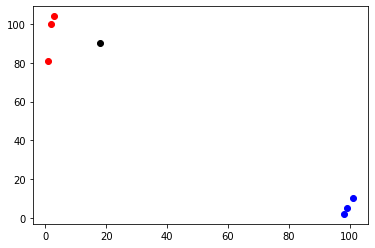

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import operator

# 已知分类数据
x1 = np.array([3,2,1])
y1 = np.array([104,100,81])
x2 = np.array([101,99,98])
y2 = np.array([10,5,2])
scatter1 = plt.scatter(x1,y1,c='r')
scatter2 = plt.scatter(x2,y2,c='b')

# 未知数据
x = np.array([18])
y = np.array([90])
scatter3 = plt.scatter(x, y, c='k')

plt.show()

In [ ]:
# 已知分类的数据
x_data = np.array([[3,104],
                  [2,100],
                  [1,81],
                  [101,10],
                  [99,5],
                  [81,2]])
y_data = np.array(['A','A','A','B','B','B'])
x_test = np.array([18,90])

In [ ]:
# 计算样本数量
x_data_size = x_data.shape[0]

In [ ]:
# 复制x_test
np.tile(x_test, (x_data_size,1))
# 计算x_test与每个样本的差值
diffMat = np.tile(x_test, (x_data_size, 1)) - x_data
# 计算差值的平方
sqDiffMat = diffMat ** 2
# 求和
sqDistances = sqDiffMat.sum(axis=1)
# 开方
distances = sqDistances ** 0.5

In [ ]:
# 从小到大排序
sortedDistances = distances.argsort()
sortedDistances

array([1, 2, 0, 5, 3, 4])

In [ ]:
classCount = {}
# 设置k
k = 5
for i in range(k):
  # 获取标签
  votelabel = y_data[sortedDistances[i]]
  # 统计标签数量
  classCount[votelabel] = classCount.get(votelabel,0) + 1

In [ ]:
classCount

{'A': 3, 'B': 2}

In [ ]:
# 根据operator.itemgetter(1)-第一个值对classCount排序，然后再取倒序
sortedClassCount = sorted(classCount.items(), key=operator.itemgetter(1), reverse=True)
sortedClassCount

[('A', 3), ('B', 2)]

In [ ]:
# 获取数量最多的标签
knnClass = sortedClassCount[0][0]
knnClass

'A'

## knn对Iris数据集分类

In [1]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
import operator
import random

In [3]:
def knn(x_test, x_data, y_data, k):
  # 计算样本数量
  x_data_size = x_data.shape[0]
  # 复制x_test
  np.tile(x_test, (x_data_size, 1))
  # 计算x_test与每个样本的差值
  diffMat = np.tile(x_test, (x_data_size, 1)) - x_data
  # 计算差值的平方
  sqDiffMat = diffMat ** 2
  # 求和
  sqDistances = sqDiffMat.sum(axis=1)
  # 开方
  distances = sqDistances ** 0.5
  # 从小到大排序
  sortedDistances = distances.argsort()
  classCount = {}
  for i in range(k):
    # 获取标签
    votelabel = y_data[sortedDistances[i]]
    # 统计标签数量
    classCount[votelabel] = classCount.get(votelabel, 0)+1
  # 根据operator.itemgetter(1):第1个值对classCount排序，然后取倒序
  sortedClassCount = sorted(classCount.items(), key=operator.itemgetter(1), reverse=True)
  return  sortedClassCount[0][0]

In [6]:
# 载入数据
iris = datasets.load_iris()
# 打乱数据
data_size = iris.data.shape[0]
index = [i for i in range(data_size)]
random.shuffle(index)
iris.data = iris.data[index]
iris.target = iris.target[index]

# 切分数据集
test_size = 40
x_train = iris.data[test_size:]
x_test = iris.data[:test_size]
y_train = iris.target[test_size:]
y_test = iris.target[:test_size]

predictions = []
for i in range(x_test.shape[0]):
  predictions.append(knn(x_test[i], x_train, y_train, 5))
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.86      1.00      0.92        12
           2       1.00      0.88      0.94        17

    accuracy                           0.95        40
   macro avg       0.95      0.96      0.95        40
weighted avg       0.96      0.95      0.95        40

